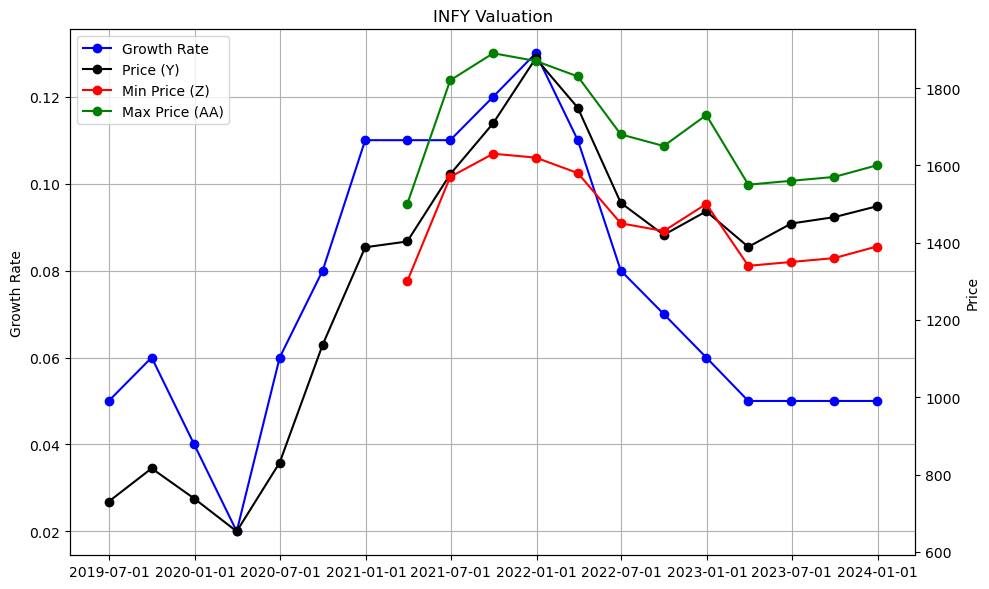

In [93]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Define the file path and ticker
ticker1 = 'INFY'
file_path_ticker1 = r'C:\MyDocuments\03Business\05ResearchAndAnalysis\StockInvestments\QuarterResultsScreenerExcels\2025Q1\{}_FY25Q1.xlsx'.format(ticker1)

# Read the Excel file into a dataframe for ticker1
df_valuation = pd.read_excel(file_path_ticker1, sheet_name='ValuationHistory', header=None)

def fiscal_quarter_to_date(fiscal_quarter):
    if pd.isna(fiscal_quarter):
        return None
    
    year = int(fiscal_quarter[2:4])  # Extract the year from fiscal quarter (e.g., 24 from FY24)
    quarter = int(fiscal_quarter[-1])  # Extract the quarter number (e.g., 3 from Q3)

    # Adjust the year and quarter for Indian financial years
    if quarter == 1:
        year = 2000 + year - 1
        month = 6
    elif quarter == 2:
        year = 2000 + year - 1
        month = 9
    elif quarter == 3:
        year = 2000 + year - 1
        month = 12
    else:  # quarter == 4
        year = 2000 + year
        month = 3

    # Construct the date string in the format 'yyyy-mm-dd'
    date_string = f'{year}-{str(month).zfill(2)}-30'

    return pd.to_datetime(date_string)

# Check for non-empty growth rate values in the first section (row 2 to row 30)
growth_rates_section1 = df_valuation.iloc[1:29, 8].dropna().tolist()

# Check for non-empty growth rate values in the second section (row 32 to row 60)
growth_rates_section2 = df_valuation.iloc[31:59, 8].dropna().tolist()

# Combine the growth rate sections to find the range
growth_rates_combined = growth_rates_section1 + growth_rates_section2

if growth_rates_combined:
    # Find the start and end row numbers for constructing the dataset
    start_row = 1 if growth_rates_section1 else 31
    end_row = 29 if growth_rates_section1 else 59

    # Construct the dataset
    data_set = []
    for i in range(start_row, min(end_row, len(df_valuation))):
        if not pd.isnull(df_valuation.iloc[i, 0]):
            date = fiscal_quarter_to_date(df_valuation.iloc[i, 0])
            growth_rate = df_valuation.iloc[i, 8]
            price = df_valuation.iloc[i, 24]  # Col Y
            min_price = df_valuation.iloc[i, 25] if pd.notnull(df_valuation.iloc[i, 25]) else None  # Col Z
            max_price = df_valuation.iloc[i, 26] if pd.notnull(df_valuation.iloc[i, 26]) else None  # Col AA
            data_set.append([date, growth_rate, price, min_price, max_price])

    # Reverse the dataset by Date
    data_set = sorted(data_set, key=lambda x: x[0])

    # Plot the data
    fig, ax1 = plt.subplots(figsize=(10, 6))
    ax1.plot([data[0] for data in data_set], [data[1] for data in data_set], marker='o', color='blue', linestyle='-', label='Growth Rate')
    ax1.set_ylabel('Growth Rate')

    # Secondary y-axis for price, minPrice, maxPrice
    ax2 = ax1.twinx()
    ax2.plot([data[0] for data in data_set], [data[2] for data in data_set], marker='o', color='black', linestyle='-', label='Price (Y)')
    ax2.plot([data[0] for data in data_set], [data[3] for data in data_set], marker='o', color='red', linestyle='-', label='Min Price (Z)')
    ax2.plot([data[0] for data in data_set], [data[4] for data in data_set], marker='o', color='green', linestyle='-', label='Max Price (AA)')
    ax2.set_ylabel('Price')

    # Format the x-axis dates
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.xticks(rotation=45, ha='right')  # Slant the dates and align them to the right

    # Add legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

    # Add grid
    ax1.grid(True)

    plt.title(f'{ticker1} Valuation')
    plt.tight_layout()
    plt.show()
else:
    print("No valuation history")
